In [1]:
import os
import re
import json
import random
import math
import numpy as np
import tensorflow as tf
from collections import Counter
from pypdf import PdfReader
from tensorflow.keras.layers import Embedding, Dot, Input, Reshape, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.callbacks import Callback
import matplotlib.pyplot as plt
import unicodedata


In [ ]:
try:
    BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
   
    BASE_DIR = os.path.dirname(os.getcwd())

In [11]:
OUTPUT_TXT = os.path.join(BASE_DIR, "storage", "Dataset para entrenar embedding", "Texto entrenamiento.txt")

In [ ]:
PDF_FOLDER = os.path.join(BASE_DIR, "storage", "Dataset para entrenar embedding")
MODEL_SAVE_PATH = os.path.join(BASE_DIR, "storage", "Modelos Generados", "modelo_skipgram_definitivo.keras")
ENC_SAVE_PATH = os.path.join(BASE_DIR, "storage", "Archivos json de los codigos", "enc_definitivo.json")
VOCAB_SAVE_PATH = os.path.join(BASE_DIR, "storage", "Archivos json de los codigos", "vocabulary_definitivo.json")
EMB_OUT = os.path.join(BASE_DIR, "storage", "Archivos json de los codigos", "embeddings_final.npy")

In [ ]:
EMBEDDING_DIM = 200            
WINDOW_SIZE = 5
MIN_WORD_FREQ = 5
SUBSAMPLING_THRESHOLD = 1e-5
NEGATIVE_SAMPLES = 10           
POSITIVE_BATCH_SIZE = 512      
LEARNING_RATE = 1e-4
L2_REG = 1e-5
MAX_NORM = 3.0

STEPS_PER_EPOCH = 3000        
EPOCHS = 12
VALIDATION_SPLIT = 0.1

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

FAST_TEST_MODE = False
FAST_TEST_WORDS = 500_000 

In [ ]:
def normalize_token(t):
     
    t = unicodedata.normalize("NFKD", t)
    t = "".join([c for c in t if not unicodedata.combining(c)])
    t = t.lower().strip()
     
    t = re.sub(r"[^a-zñ0-9]", "", t)
   
    if len(t) < 3:
        return None
    if any(ch.isdigit() for ch in t) and sum(ch.isdigit() for ch in t) / len(t) > 0.5:
        return None
    return t

In [13]:
if not os.path.exists(OUTPUT_TXT):
    all_text = []
    for filename in os.listdir(PDF_FOLDER):
        print(filename)
        if filename.lower().endswith(".pdf"):
            pdf_path = os.path.join(PDF_FOLDER, filename)
            reader = PdfReader(pdf_path, strict=False)
            for page in reader.pages:
                try:
                    text = page.extract_text()
                    if text:
                        all_text.append(text)
                except Exception:
                    continue
    with open(OUTPUT_TXT, "w", encoding="utf-8") as f:
        f.write("\n".join(all_text))

In [ ]:
def tokenize_line(line):
     
    line = line.lower()
    line = re.sub(r"[-–—_]", " ", line)
     
    line = re.sub(r"[^a-záéíóúüñ0-9\s]", " ", line)
    toks = [normalize_token(t) for t in line.split()]
    toks = [t for t in toks if t is not None]
    return toks

In [15]:
with open(OUTPUT_TXT, "r", encoding="utf-8") as f:
    raw_lines = f.readlines()

raw_lines


['~\n',
 '=:;\n',
 'Instituto\n',
 'Politécnico\n',
 'Nacional\n',
 '~\n',
 'i\n',
 '.\n',
 'j\n',
 '11\n',
 '11\n',
 'ENFOQUE LÓGICO\n',
 '. COMBINATORIO\n',
 'AL RECONOCIMIENTO\n',
 'DE PATRONES\n',
 '1. SELECCiÓN DEVARIABLES\n',
 '. Y CLASIFICACiÓN SUPERVISADA\n',
 '~.~\n',
 '\n',
 '-.\n',
 'i\n',
 '\\\n',
 '\\\n',
 'h\n',
 '{i\n',
 'II~\n',
 '.\n',
 '!\n',
 'I~\n',
 '~\n',
 ',11\n',
 'I1\n',
 ':~¡!\n',
 '"\n',
 '- 11\n',
 '.\n',
 '..\n',
 '~,\n',
 'EL PRESENTE LIBRO ES EL PRIMERO EN IBEROAMÉRICA EN\n',
 'OFRECER UNA INTRODUCCiÓN AL ENFOQUE LÓGICO\n',
 'COMBINATORIO DE RECONOCIMIENTO DE PATRONES. Es DE\n',
 'HECHO LA PRIMERA OBRA CON FINES DOCENTE~ PUBLIcADA\n',
 'A ESCALA MUNDIAL. A ESTE TRABAJO LO PRECEDIERON\n',
 'OTROS CON FINES SIMILARES PE~O CON UN ALCANCE DE\n',
 'DIVULGACiÓN MUCHO MENOR. SE HA PRETENDIDO ELABORAR\n',
 'UN MATERIAL EN EL QUE SE EXPONE DE MANERA CLARA Y\n',
 'DIRECTA LA TEORíA Y HERRAMIENTAS PARA RESOLVER\n',
 'PROBLEMAS DE SELECCiÓN DE VARIABLES (DETERMINACiÓ

In [8]:
sentences = []
for line in raw_lines:
    toks = tokenize_line(line)
    if len(toks) > 2:
        sentences.append(toks)

sentences

[['presente', 'libro', 'primero', 'iberoamerica'],
 ['ofrecer', 'una', 'introduccion', 'enfoque', 'logico'],
 ['combinatorio', 'reconocimiento', 'patrones'],
 ['hecho', 'primera', 'obra', 'con', 'fines', 'docente', 'publicada'],
 ['escala', 'mundial', 'este', 'trabajo', 'precedieron'],
 ['otros', 'con', 'fines', 'similares', 'con', 'alcance'],
 ['divulgacion', 'mucho', 'menor', 'pretendido', 'elaborar'],
 ['material', 'que', 'expone', 'manera', 'clara'],
 ['directa', 'teoria', 'herramientas', 'para', 'resolver'],
 ['problemas', 'seleccion', 'variables', 'determinacion'],
 ['sindromes', 'enfermedades', 'determinacion'],
 ['relevancia', 'sintomas', 'signos', 'enfermedades'],
 ['del', 'estado', 'tecnico', 'equipds', 'etc', 'clasificacion'],
 ['pervi', 'con', 'apr', 'dizaj', 'diag', 'nostico'],
 ['pronostico', 'medicos', 'pronostico', 'fenomenos'],
 ['naturales', 'sociales', 'pronostico', 'perspectividad'],
 ['recursos', 'minerales', 'etc', 'partir', 'del', 'enfoque'],
 ['logico', 'combina

In [9]:
if FAST_TEST_MODE:
    print(f"\n*** MODO PRUEBA RÁPIDA: usando primeras {FAST_TEST_WORDS} palabras ***")
    word_count = 0
    truncated_sentences = []
    for sent in sentences:
        if word_count + len(sent) <= FAST_TEST_WORDS:
            truncated_sentences.append(sent)
            word_count += len(sent)
        else:
            remaining = FAST_TEST_WORDS - word_count
            if remaining > 0:
                truncated_sentences.append(sent[:remaining])
            break
    sentences = truncated_sentences
    print(f"Frases después de truncar: {len(sentences)}")

In [10]:

with open(ENC_SAVE_PATH,"r", encoding="utf-8") as f:   
    word_to_idx = json.load(f)

with open(VOCAB_SAVE_PATH,"r", encoding="utf-8") as f:
    vocabulary = json.load(f)


In [11]:
word_counts = Counter()
for s in sentences:
    word_counts.update(s)
total_words = sum(word_counts.values())
print(f"Total de palabras en el corpus: {total_words}")

Total de palabras en el corpus: 6228694


In [14]:
vocabulary = [w for w, c in word_counts.items() if c >= MIN_WORD_FREQ]
print(f"Tamaño del vocabulario (freq >= {MIN_WORD_FREQ}): {len(vocabulary)}")
vocabulary

Tamaño del vocabulario (freq >= 5): 39234


['presente',
 'libro',
 'primero',
 'ofrecer',
 'una',
 'introduccion',
 'enfoque',
 'logico',
 'combinatorio',
 'reconocimiento',
 'patrones',
 'hecho',
 'primera',
 'obra',
 'con',
 'fines',
 'docente',
 'publicada',
 'escala',
 'mundial',
 'este',
 'trabajo',
 'otros',
 'similares',
 'alcance',
 'mucho',
 'menor',
 'pretendido',
 'elaborar',
 'material',
 'que',
 'expone',
 'manera',
 'clara',
 'directa',
 'teoria',
 'herramientas',
 'para',
 'resolver',
 'problemas',
 'seleccion',
 'variables',
 'determinacion',
 'sindromes',
 'enfermedades',
 'relevancia',
 'sintomas',
 'signos',
 'del',
 'estado',
 'tecnico',
 'etc',
 'clasificacion',
 'apr',
 'diag',
 'nostico',
 'pronostico',
 'medicos',
 'fenomenos',
 'naturales',
 'sociales',
 'perspectividad',
 'recursos',
 'minerales',
 'partir',
 'las',
 'llamadas',
 'zonas',
 'conocimiento',
 'poco',
 'formalizadas',
 'los',
 'supervisada',
 'parcialmente',
 'han',
 'segundo',
 'tomo',
 'importancia',
 'esta',
 'rama',
 'radica',
 'medici

In [15]:
word_to_idx = {w: i for i, w in enumerate(vocabulary)}
idx_to_word = {i: w for w, i in word_to_idx.items()}
idx_to_word

{0: 'presente',
 1: 'libro',
 2: 'primero',
 3: 'ofrecer',
 4: 'una',
 5: 'introduccion',
 6: 'enfoque',
 7: 'logico',
 8: 'combinatorio',
 9: 'reconocimiento',
 10: 'patrones',
 11: 'hecho',
 12: 'primera',
 13: 'obra',
 14: 'con',
 15: 'fines',
 16: 'docente',
 17: 'publicada',
 18: 'escala',
 19: 'mundial',
 20: 'este',
 21: 'trabajo',
 22: 'otros',
 23: 'similares',
 24: 'alcance',
 25: 'mucho',
 26: 'menor',
 27: 'pretendido',
 28: 'elaborar',
 29: 'material',
 30: 'que',
 31: 'expone',
 32: 'manera',
 33: 'clara',
 34: 'directa',
 35: 'teoria',
 36: 'herramientas',
 37: 'para',
 38: 'resolver',
 39: 'problemas',
 40: 'seleccion',
 41: 'variables',
 42: 'determinacion',
 43: 'sindromes',
 44: 'enfermedades',
 45: 'relevancia',
 46: 'sintomas',
 47: 'signos',
 48: 'del',
 49: 'estado',
 50: 'tecnico',
 51: 'etc',
 52: 'clasificacion',
 53: 'apr',
 54: 'diag',
 55: 'nostico',
 56: 'pronostico',
 57: 'medicos',
 58: 'fenomenos',
 59: 'naturales',
 60: 'sociales',
 61: 'perspectividad

In [12]:
vocab_size = len(vocabulary)
vocab_size

39234

In [13]:
def subsampling_prob(word, threshold=SUBSAMPLING_THRESHOLD):
    freq = word_counts[word] / total_words
    if freq > threshold:
        prob_keep = (math.sqrt(freq / threshold) + 1) * (threshold / freq)
        return min(prob_keep, 1.0)
    return 1.0

In [14]:

if SUBSAMPLING_THRESHOLD > 0:
    subsampled = []
    for sent in sentences:
        new_sent = [w for w in sent if w in word_to_idx and random.random() < subsampling_prob(w)]
        if new_sent:
            subsampled.append(new_sent)
    sentences = subsampled
    print("Sentences after subsampling:", len(sentences))


Sentences after subsampling: 707647


In [15]:
random.shuffle(sentences)
split_idx = int(len(sentences) * (1.0 - VALIDATION_SPLIT))
train_sentences = sentences[:split_idx]
val_sentences = sentences[split_idx:]

In [16]:
freqs = np.array([word_counts.get(w,1) for w in vocabulary], dtype=np.float64)
word_freqs = freqs ** 0.75
word_freqs /= word_freqs.sum()

def sample_negatives_by_freq(k):
    return np.random.choice(vocab_size, size=k, p=word_freqs, replace=True)

In [ ]:
def positive_pair_generator(sentences, word_to_idx, window_size):
 
    while True:
        sent = random.choice(sentences)
        L = len(sent)
        if L < 2:
            continue
        i = random.randrange(L)
        target = sent[i]
        if target not in word_to_idx:
            continue
        start = max(0, i - window_size)
        end = min(L, i + window_size + 1)
        
        j = random.choice([x for x in range(start, end) if x != i])
        context = sent[j]
        if context not in word_to_idx:
            continue
        yield word_to_idx[target], word_to_idx[context]

def batch_generator(sentences, word_to_idx, pos_batch_size, negative_samples, window_size):
    pos_gen = positive_pair_generator(sentences, word_to_idx, window_size)
    while True:
        targets, contexts, labels = [], [], []
        for _ in range(pos_batch_size):
            t_idx, c_idx = next(pos_gen)
            targets.append(t_idx); contexts.append(c_idx); labels.append(1.0)
            negs = sample_negatives_by_freq(negative_samples)
            for n in negs:
                targets.append(t_idx); contexts.append(int(n)); labels.append(0.0)
      
        yield (np.array(targets, dtype=np.int32).reshape(-1,1),
               np.array(contexts, dtype=np.int32).reshape(-1,1)), \
              np.array(labels, dtype=np.float32)


In [18]:
AUTOTUNE = tf.data.AUTOTUNE

def make_tf_dataset(sentences_local, word_to_idx_local, pos_batch_size, negative_samples, window_size_local, prefetch=2):
    gen = lambda: batch_generator(sentences_local, word_to_idx_local, pos_batch_size, negative_samples, window_size_local)
    output_types = ((tf.int32, tf.int32), tf.float32)
    output_shapes = (((None,1),(None,1)), (None,))
    ds = tf.data.Dataset.from_generator(gen, output_types=output_types, output_shapes=output_shapes)
    ds = ds.prefetch(prefetch)
    return ds

In [19]:
train_ds = make_tf_dataset(train_sentences, word_to_idx, POSITIVE_BATCH_SIZE, NEGATIVE_SAMPLES, WINDOW_SIZE, prefetch=AUTOTUNE)
val_ds = make_tf_dataset(val_sentences, word_to_idx, POSITIVE_BATCH_SIZE, NEGATIVE_SAMPLES, WINDOW_SIZE, prefetch=AUTOTUNE)

In [20]:
steps_per_epoch = max(1, min(STEPS_PER_EPOCH, len(train_sentences) // POSITIVE_BATCH_SIZE))
validation_steps = max(1, len(val_sentences) // POSITIVE_BATCH_SIZE)
print("steps_per_epoch:", steps_per_epoch, "validation_steps:", validation_steps)

steps_per_epoch: 1243 validation_steps: 138


In [21]:
class EmbeddingNormLogger(Callback):
    def __init__(self, every_n_epochs=1):
        super().__init__()
        self.every_n_epochs = every_n_epochs

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n_epochs != 0:
            return
        try:
            t_w = self.model.get_layer("target_emb").get_weights()[0]
            c_w = self.model.get_layer("context_emb").get_weights()[0]
            t_norms = np.linalg.norm(t_w, axis=1)
            c_norms = np.linalg.norm(c_w, axis=1)
            print(f"[Epoch {epoch+1}] target mean:{t_norms.mean():.4f} max:{t_norms.max():.4f} | context mean:{c_norms.mean():.4f} max:{c_norms.max():.4f}")
        except Exception as e:
            print("Norm logger error:", e)

In [22]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor='val_loss', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    EmbeddingNormLogger(every_n_epochs=1)
]

In [23]:
target_input = Input((1,), name="target")
context_input = Input((1,), name="context")

initializer = tf.keras.initializers.RandomUniform(minval=-0.1, maxval=0.1)

target_embedding = Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    embeddings_regularizer=tf.keras.regularizers.l2(L2_REG),
    embeddings_constraint=max_norm(MAX_NORM),
    embeddings_initializer=initializer,
    name="target_emb"
)(target_input)

context_embedding = Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    embeddings_regularizer=tf.keras.regularizers.l2(L2_REG),
    embeddings_constraint=max_norm(MAX_NORM),
    embeddings_initializer=initializer,
    name="context_emb"
)(context_input)

c:\Osmay\Escuela\UCI\Tesis\IA para asistencia en soporte de negocios\Codigos Separados\VE\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer RandomUniform is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


In [24]:
t_norm = Lambda(lambda x: tf.math.l2_normalize(x, axis=-1), name="t_norm")(target_embedding)
c_norm = Lambda(lambda x: tf.math.l2_normalize(x, axis=-1), name="c_norm")(context_embedding)

dot = Dot(axes=-1)([t_norm, c_norm])
dot = Reshape((1,))(dot)

In [25]:
model = Model(inputs=[target_input, context_input], outputs=dot)
optimizer = Adam(learning_rate=LEARNING_RATE, clipnorm=5.0)
model.compile(optimizer=optimizer, loss=tf.keras.losses.BinaryCrossentropy(from_logits=True))
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 target (InputLayer)            [(None, 1)]          0           []                               
                                                                                                  
 context (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 target_emb (Embedding)         (None, 1, 200)       7846800     ['target[0][0]']                 
                                                                                                  
 context_emb (Embedding)        (None, 1, 200)       7846800     ['context[0][0]']                
                                                                                              

In [30]:
model.fit(train_ds, steps_per_epoch=steps_per_epoch, epochs=EPOCHS,
          validation_data=val_ds, validation_steps=validation_steps,
          callbacks=callbacks, verbose=1)

Epoch 1/12
1243/1243 [==============================] - ETA: 0s - loss: 0.6860
Epoch 1: val_loss improved from inf to 0.56983, saving model to C:\Osmay\Escuela\UCI\Tesis\IA para asistencia en soporte de negocios\Codigos Separados\Tesis completada\storage\Modelos Generados\modelo_skipgram_definitivo.keras
[Epoch 1] target mean:0.1082 max:0.2237 | context mean:0.1527 max:0.2318
1243/1243 [==============================] - 155s 121ms/step - loss: 0.6860 - val_loss: 0.5698 - lr: 1.0000e-04
Epoch 2/12
1243/1243 [==============================] - ETA: 0s - loss: 0.4817
Epoch 2: val_loss improved from 0.56983 to 0.43793, saving model to C:\Osmay\Escuela\UCI\Tesis\IA para asistencia en soporte de negocios\Codigos Separados\Tesis completada\storage\Modelos Generados\modelo_skipgram_definitivo.keras
[Epoch 2] target mean:0.1020 max:0.2142 | context mean:0.1144 max:0.2253
1243/1243 [==============================] - 149s 120ms/step - loss: 0.4817 - val_loss: 0.4379 - lr: 1.0000e-04
Epoch 3/12
124

In [31]:
model.save(MODEL_SAVE_PATH)
with open(ENC_SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump(word_to_idx, f, ensure_ascii=False)
with open(VOCAB_SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump(vocabulary, f, ensure_ascii=False)
print("Model and dictionaries saved.")

Model and dictionaries saved.


In [32]:
t_w = model.get_layer("target_emb").get_weights()[0]
c_w = model.get_layer("context_emb").get_weights()[0]
final_emb = (t_w + c_w) / 2.0
final_emb = final_emb / (np.linalg.norm(final_emb, axis=1, keepdims=True) + 1e-12)
np.save(EMB_OUT, final_emb)
print("Embeddings guardados en:", EMB_OUT)

Embeddings guardados en: C:\Osmay\Escuela\UCI\Tesis\IA para asistencia en soporte de negocios\Codigos Separados\Tesis completada\storage\Archivos json de los codigos\embeddings_final.npy


In [ ]:
def load_embeddings_and_enc(emb_path=EMB_OUT, enc_path=ENC_SAVE_PATH):
    emb = np.load(emb_path)
    with open(enc_path, "r", encoding="utf-8") as f:
        enc = json.load(f)  
    if len(enc) != emb.shape[0]:
        raise ValueError(f"Mismatch: len(enc)={len(enc)} vs emb.shape={emb.shape}")
     
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    norms[norms==0] = 1.0
    emb = emb / norms
    return emb, enc

In [27]:
def get_vector(word, emb, enc):
    idx = enc.get(word)
    return emb[idx] if idx is not None else None

In [28]:
def cosine_similarity(v1, v2):
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

In [29]:
def most_similar(word, emb, enc, topn=10):
    vec = get_vector(word, emb, enc)
    if vec is None:
        return []
    sims = [(w, cosine_similarity(vec, emb[i])) for w,i in enc.items() if w != word]
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:topn]

In [30]:
def sample_similarity_hist(emb, enc, n=3000):
    vocab = list(enc.keys())
    sims = []
    for _ in range(n):
        a,b = np.random.choice(vocab, 2, replace=True)
        v1 = emb[enc[a]]; v2 = emb[enc[b]]
        sims.append(cosine_similarity(v1, v2))
    return np.array(sims)

shape emb: (39234, 200)
Top vecinos de 'ingeniería': [('the', 0.9170834422111511), ('con', 0.9169086217880249), ('this', 0.9164566993713379), ('desiguales', 0.9161174893379211), ('local0', 0.9157503247261047), ('retribucion', 0.9153919219970703), ('para', 0.9151164889335632), ('and', 0.9149762988090515), ('can', 0.914893627166748), ('ecpgget', 0.914871335029602)]
mean,std,min,max: 0.2736162090255646 0.3897480703694573 -0.9560929536819458 0.9556072354316711


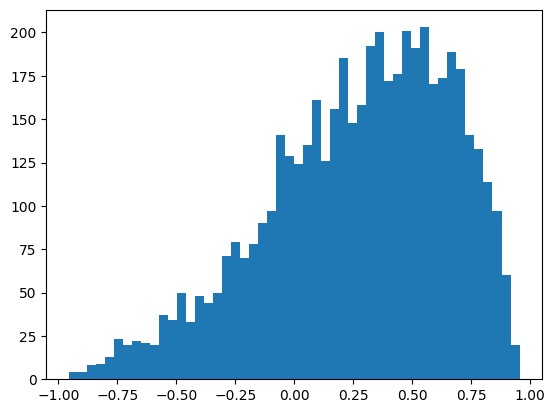

In [31]:
emb_matrix, enc = load_embeddings_and_enc()
print("shape emb:", emb_matrix.shape)
print("Top vecinos de 'ingeniería':", most_similar("datos", emb_matrix, enc, topn=10))

sims = sample_similarity_hist(emb_matrix, enc, n=5000)
print("mean,std,min,max:", sims.mean(), sims.std(), sims.min(), sims.max())
plt.hist(sims, bins=50); plt.show()

asafdfasgsdhgsdhdfhg

In [ ]:
import numpy as np
import json

 
emb = np.load(EMB_OUT)
with open(ENC_SAVE_PATH, "r", encoding="utf-8") as f:
    enc = json.load(f)  

 
norms = np.linalg.norm(emb, axis=1, keepdims=True)
norms[norms == 0] = 1.0
emb = emb / norms

def get_vector(word):
    idx = enc.get(word)
    return emb[idx] if idx is not None else None

def cosine(v1, v2):
    if v1 is None or v2 is None:
        return None
    return float(np.dot(v1, v2))

def cosine_01(c):
    return None if c is None else (c + 1.0) / 2.0

 
pairs_similar = [
    ("ingenieria", "ingenieria"),
    ("datos", "que"),
    ("libro", "texto"),
    ("universidad", "facultades"),
    ("diagnostico", "medicos"),
    ("procesamiento", "imagenes"),
    ("algoritmos", "geneticos"),
    ("redes", "neuronales"),
    ("matematica", "fisica"),
    ("automatizacion", "electronica")
]

pairs_different = [
    ("libro", "terremotos"),
    ("ingenieria", "pan"),
    ("datos", "pintura"),
    ("universidad", "telefono"),
    ("diagnostico", "pintura"),
    ("procesamiento", "pan"),
    ("algoritmos", "pan"),
    ("redes", "pintura"),
    ("matematica", "pan"),
    ("automatizacion", "pintura")
]

 
if __name__ == "__main__":
  
    print("=== Pares similares ===")
    for a, b in pairs_similar:
        v1 = get_vector(a)
        v2 = get_vector(b)
        cos = cosine(v1, v2)
        cos01 = (cos + 1.0) / 2.0 if cos is not None else None
        print(f"{a:15} - {b:15} : cos={cos}  mapped=[0,1]={cos01}")

 
    print("\n=== Pares diferentes ===")
    for a, b in pairs_different:
        v1 = get_vector(a)
        v2 = get_vector(b)
        cos = cosine(v1, v2)
        cos01 = (cos + 1.0) / 2.0 if cos is not None else None
        print(f"{a:15} - {b:15} : cos={cos}  mapped=[0,1]={cos01}")

=== Pares similares ===
ingenieria      - ingenieria      : cos=1.0000001192092896  mapped=[0,1]=1.0000000596046448
datos           - que             : cos=0.9039595127105713  mapped=[0,1]=0.9519797563552856
libro           - texto           : cos=0.03775300085544586  mapped=[0,1]=0.5188765004277229
universidad     - facultades      : cos=-0.09016339480876923  mapped=[0,1]=0.4549183025956154
diagnostico     - medicos         : cos=0.731182336807251  mapped=[0,1]=0.8655911684036255
procesamiento   - imagenes        : cos=0.11304411292076111  mapped=[0,1]=0.5565220564603806
algoritmos      - geneticos       : cos=0.4791743755340576  mapped=[0,1]=0.7395871877670288
redes           - neuronales      : cos=0.6677318811416626  mapped=[0,1]=0.8338659405708313
matematica      - fisica          : cos=0.6715421080589294  mapped=[0,1]=0.8357710540294647
automatizacion  - electronica     : cos=0.6829164624214172  mapped=[0,1]=0.8414582312107086

=== Pares diferentes ===
libro           - terremoto

In [40]:
vocabulary

['presente',
 'libro',
 'primero',
 'ofrecer',
 'una',
 'introduccion',
 'enfoque',
 'logico',
 'combinatorio',
 'reconocimiento',
 'patrones',
 'hecho',
 'primera',
 'obra',
 'con',
 'fines',
 'docente',
 'publicada',
 'escala',
 'mundial',
 'este',
 'trabajo',
 'otros',
 'similares',
 'alcance',
 'mucho',
 'menor',
 'pretendido',
 'elaborar',
 'material',
 'que',
 'expone',
 'manera',
 'clara',
 'directa',
 'teoria',
 'herramientas',
 'para',
 'resolver',
 'problemas',
 'seleccion',
 'variables',
 'determinacion',
 'sindromes',
 'enfermedades',
 'relevancia',
 'sintomas',
 'signos',
 'del',
 'estado',
 'tecnico',
 'etc',
 'clasificacion',
 'apr',
 'diag',
 'nostico',
 'pronostico',
 'medicos',
 'fenomenos',
 'naturales',
 'sociales',
 'perspectividad',
 'recursos',
 'minerales',
 'partir',
 'las',
 'llamadas',
 'zonas',
 'conocimiento',
 'poco',
 'formalizadas',
 'los',
 'supervisada',
 'parcialmente',
 'han',
 'segundo',
 'tomo',
 'importancia',
 'esta',
 'rama',
 'radica',
 'medici